# Implementing Linear Regression from Scratch

This template is provided for you to train a linear regression model from scratch using your project dataset.
Fill in the __None__ parts in this template.

__Notes:__
1. Please follow the instructions in this notebook to complete all the tasks as specified.
2. Do not change the order of the cells, and do not modify the test cells provided to verify if you have implemented the functions correctly.

### Importing the required packages

In [2]:
# Put your code here (3 lines of code)
# Import the required packages: numpy, pandas, matplotlib.pyplot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Project dataset

In [3]:
# Put your code here (1 line of code)
# Load your project dataset 
data = pd.read_csv("diabetic_data.csv")

# Let's have a look on your dataset
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Response and feature selection

Select a single variable from your project dataset as the response variable for your linear regression model and identify at least three potential features. You will not be evaluated based on the number of features you consider; the effectiveness of your implementation is more important. 

In [4]:
# Put your code here (1 line of code)
# Choose your target 
target_variable = ["time_in_hospital"]

Target = data[target_variable] 

Let's compute the correlation for the numerical features to gain insight into which features are potential predictor variables in the linear regression model.

In [7]:
#data.corr()

In [13]:
# Put your code here (1 line of code)
# Choose your feature
feature_variables = ["admission_type_id", "discharge_disposition_id", "admission_source_id", "num_lab_procedures", "num_procedures", "num_medications", "number_emergency", "number_inpatient", "number_outpatient", "number_diagnoses"]

# Now let's have a look at the features you have chosen
Features = data[feature_variables]
Features.head()

,admission_type_id,discharge_disposition_id,admission_source_id,num_lab_procedures,num_procedures,num_medications,number_emergency,number_inpatient,number_outpatient,number_diagnoses
0,6,25,1,41,0,1,0,0,0,1
1,1,1,7,59,0,18,0,0,0,9
2,1,1,7,11,5,13,0,1,2,6
3,1,1,7,44,1,16,0,0,0,7
4,1,1,7,51,0,8,0,0,0,5


### Training and test sets

In [14]:
# Split your dataset into training and test sets
# You can use scikit-learn to that end
from sklearn.model_selection import train_test_split
Features_train, Features_test, Target_train, Target_test = train_test_split(Features, Target, test_size=0.2, random_state=58)

print(f"Training data shape: {Features_train.shape}, {Target_train.shape}")
print(f"Test data shape: {Features_test.shape}, {Target_test.shape}")

Training data shape: (81412, 10), (81412, 1)
Test data shape: (20354, 10), (20354, 1)


### Feature Normalization

Here, we use the __MinMaxScaler__ to normalize the range of features in the dataset, transforming the data so that all feature values fall between 0 and 1.

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(Features_train)
Y_train = Target_train.to_numpy()

In [16]:
Y_train.shape

(81412, 1)

### Important Note


To use this template for building your model, X and Y should be  two-dimensional numpy arrays. 

In [17]:
# Define the number of observations and the features (predictors)
# m denotes the number of observations
m = X_train.shape[0]
print('Number of observations:', m)

# p denotes the number of features
p = X_train.shape[1]
print('Number of features:', p)

Number of observations: 81412
Number of features: 10


You have to add 1 to the related row for each observation; i.e. we need to change X to the following form:

$$ X= \left[ \begin{array}{ccccc} 1 & x_1^{(1)} & x_2^{(1)} & \cdots & x_p^{(1)}  \\  1 & x_1^{(2)} & x_2^{(2)} & \cdots & x_p^{(2)} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\
   1 & x_1^{(m)} & x_2^{(m)} & \cdots & x_p^{(m)}  \end{array} \right]$$

In [19]:
# Put your code here (1 line of code)
# Add 1 to each row of X (you can use np.insert)
X = np.insert(X_train, 0, 1, axis=1)

print(X)

[[1.         0.         0.         ... 0.         0.         0.53333333]
 [1.         0.         0.18518519 ... 0.         0.         0.13333333]
 [1.         0.         0.18518519 ... 0.04761905 0.         0.46666667]
 ...
 [1.         0.         0.         ... 0.04761905 0.         0.33333333]
 [1.         0.         0.62962963 ... 0.04761905 0.         0.53333333]
 [1.         0.14285714 0.         ... 0.19047619 0.         0.53333333]]


In [20]:
# Let's define Y variable
Y = Y_train
print(Y)

[[ 3]
 [ 1]
 [ 6]
 ...
 [ 4]
 [ 3]
 [14]]


Use **np.random.seed** to set the seed for the NumPy pseudo-random number generator. The pseudo-random number generator produces sequences of numbers that appear random, but they are actually determined by an initial seed value. By setting the seed, you ensure that you get reproducible results when generating random numbers. __Don't change the seed number in the following cell__.

In [21]:
np.random.seed(1979)

## Linear Regression without Regularization

### Initilize Parameters


Initialize the model parameters with random values. Write a function to initialize the parameters with random values. Note that, due to having an intercept in the linear regression model, the number of parameters should be $p+1$.

In [22]:
def Init_param(p):
    # p (scalar): number of parameters
    
    # Output:
    # W: 1-dimensional numpy array
    
    # Put your code here (1 line of code)
    # Use np.random.rand to initialize the parameters
    # Note that W should have p+1 parameters
    W =  np.random.rand(p+1)
    
    return(W)

#### Test Init_param function

Now, let's check your `Init_param` function. Run the followng cell:

In [23]:
Init_param(3)

array([0.97820931, 0.75000953, 0.55963445, 0.10992111])

The expected value is as follows:

__array([0.97820931,  0.75000953,  0.55963445,  0.10992111])__

### Define Linear Regression Model


In this section, you will define your linear regression model. The model is as follows:

$$y = xW$$

Note thst here $x$ is a row vector.

In [28]:
def LR_model(x, W):
    
    # x: 1-dimensional numpy array containing the features (predictors)
    # W: 1-dimensional numpy array containg the weights of the model
    x = np.insert(x, 0, 1)
    W = np.expand_dims(W, axis=1)
    
    # Put your code here (1 line of code)
    # Implement the linear regression model
    y = x @ W
    
    return y

#### Test LR_model function

Now, let's check `LR_model` that you have already implemented. Run the following cell:

In [29]:
w = np.array([0.8, 0.7 , -0.5 , 0.3])
x = np.array([0.33,    0.5,    0.7])
LR_model(x, w)

array([0.991])

The expected output is: **array([0.991])**

### Compute Cost Function 


In this section, you are supposed to write a function to calculate the cost function. Actually, you need to implement the following cost function:

$$J(W)=\dfrac{1}{2m}(XW-Y)^\top(XW-Y)$$

In [104]:
def cost_fun(X,Y,W):
    # X: a 2-dimensional numpy array containg all the features 
    # Y: a 2-dimensional numpy array containing all the response variables
    # W: 1-dimensional numpy array containg the weights of the model
    
    # Put your code here (1 line of code)
    # Define the number of observations
    m = X.shape[0]
    
    # expand the dimension to be able to perform the matrix multiplication
    W = np.expand_dims(W, axis=1)
    
    # Put your code here (1 line of code)
    # Define the cost function using the vectorized form
    J = (1 / (2 * m)) * np.transpose(X @ W - Y) @ (X @ W - Y)
    
    
    return np.squeeze(J)

#### Test cost_fun

Now, let's check your already developed `cost_fun` function by running the following cell. Compare your result with the expected value. 

In [105]:
X1 = np.array([[1.        , 0.70175439, 1.        , 1.        ],
               [1.        , 0.49122807, 0.33333333, 1.        ],
               [1.        , 0.74561404, 0.66666667, 1.        ]])
          
Y1 = np.array([[0.68191414],
               [0.68261787],
               [0.6783955 ]])
          
W1 = np.array([3, 2, -1, 5])
cost_fun(X1,Y1,W1)

array(31.5747073)

The expected value is: **array(31.5747073)**

### Gradient Descent Update Rule without Regularization


Now, you can implement Gradient Descent update rule (without regularization) utilizing your previousely developed functions. Actually, you have to implement the following rule here:

$$W := W - \alpha \dfrac{1}{m}X^\top(XW-Y)$$

In [106]:
def grad_descent_step_wr(X, Y, W, alf):
    
    # X: a 2-dimensional numpy array containg all the features 
    # Y: a 2-dimensional numpy array containing all the response variables
    # W: 1-dimensional numpy array containg the weights of the model
    # alf: learning rate
    
    # Put your code here (1 line of code)
    # Define the number of observations
    m = X.shape[0]
    
    # Add one dimension to make the matrix multiplication possible
    W = np.expand_dims(W, axis=1)
    
    # Put your code here (1 line of code)
    # Implement the update rule
    W_new = W - alf * (1 / m) * np.transpose(X) @ (X @ W - Y)
    
    return np.squeeze(W_new)

#### Test grad_descent_step_wr

Now, let's check the `grad_descent_step_wr` function (without regularization). Run the following cell and compare the obtained result with the expected one.

In [107]:
X2 = np.array([[1.        , 0.70175439, 1.        , 1.        ],
              [1.        , 0.49122807, 0.33333333, 1.        ],
              [1.        , 0.74561404, 0.66666667, 1.        ]])
          
Y2 = np.array([[0.68191414],
              [0.68261787],
              [0.6783955 ]])

W2 = np.array([3, 2, -1, 5])

grad_descent_step_wr(X2, Y2, W2, alf=0.001)

array([ 2.99205524,  1.99486469, -1.00526929,  4.99205524])

The expected value is as follows:

**array([ 2.99205524,  1.99486469, -1.00526929,  4.99205524])**

### Implement Gradient Descent Algorithm without Regularization


Now, it is time to put together all the previously developed functions to build a linear regression model from scratch.

In [118]:
# Put your code here (1 line of code)
# Choose an initial value for model parameters, use Init_param function
w_init = Init_param(p)

# Put your code here (1 line of code)
# Choose the learning rate
alf = 0.005

# Put your code here (1 line of code)
# Choose the number of iterations
N = 20000

# Save the values for W and the COST values
W = np.zeros((p + 1, N+1))
COST = np.zeros(N + 1)

# Save initial values
W[:,0] = np.squeeze(w_init)
COST[0] = cost_fun(X, Y, w_init)

# This is for loop to implement the Gradient Descent algorithm
for n in range(N):
    
    # Put your code here (1 line of code)
    # Use grad_descent_step to update the values for w
    w_new = grad_descent_step_wr(X, Y, W[:,n], alf)
    
    # Save the new value for w
    W[:, n + 1] = w_new
    
    # Put your code here (1 line of code)
    # Save the cost value for newly obtained w using the cost_fun
    COST[n+1] = cost_fun(X,Y,w_new)


#### Plot the cost function values versus iteration

Now that you have trained your model, it is time to plot the cost function versus the iterations to check how the optimization problem converges to the optimal solution.

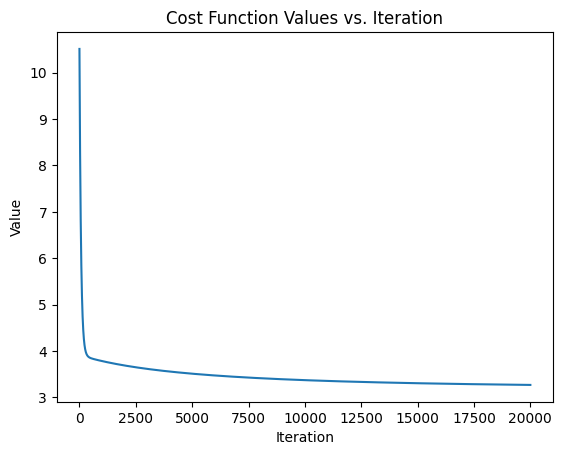

In [119]:
# Put your code here (1 line of code)
# Plot the cost function values per iteration; these values are already saved in COST.
plt.plot(COST)

plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Cost Function Values vs. Iteration')
plt.show()

#### Plot the model coefficients versus iteration

Now, to take it one step further, let's plot each coefficient versus the iterations.

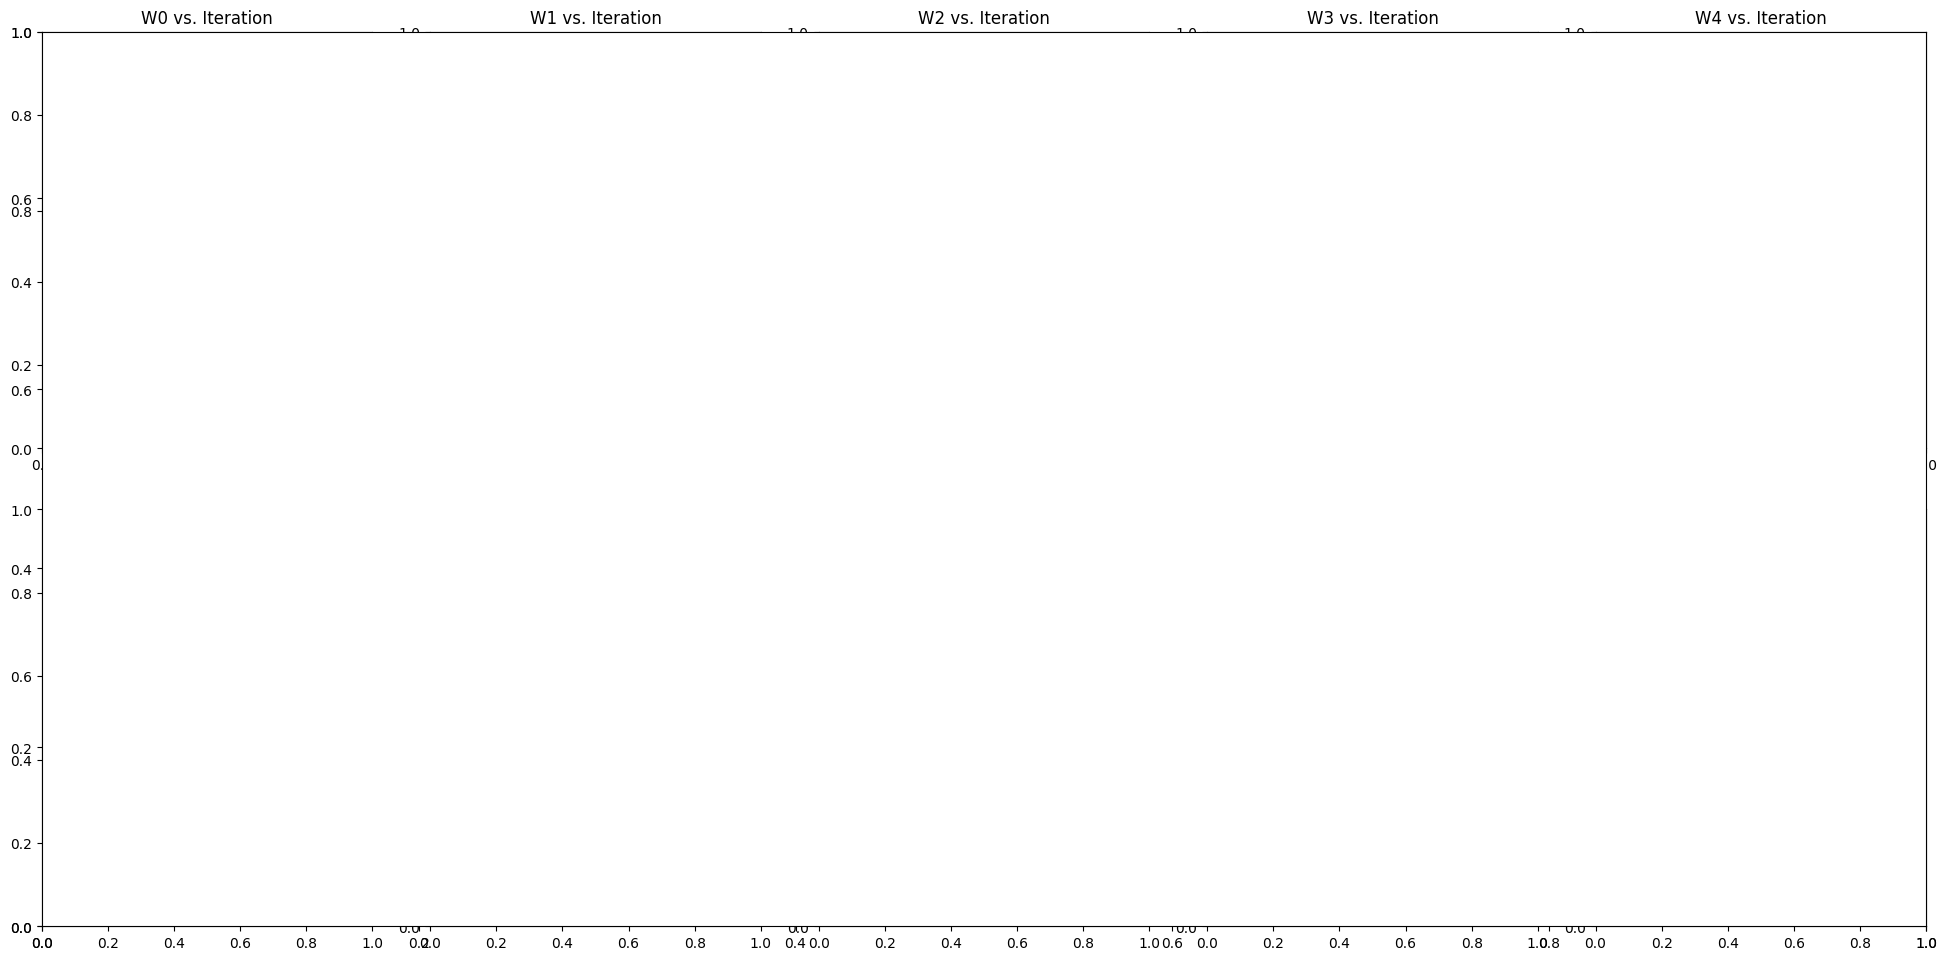

In [110]:
# Put your code here (1 lines of code)
# Choose number of rows and columns for illustrating W vs. Iteration
# Create a grid of subplots 
# You can change the number of rows and columns in the subplot
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

# Put your code here (2 lines of code)
# Plot on the first subplot W[0] vs. Iteration
plt.subplot(1,1,1)
axes[0,0].set_title(label="W0 vs. Iteration")

# Put your code here (2 line of code)
# Plot on the second subplot W[1] vs. Iteration
plt.subplot(1,1,1)
axes[0,1].set_title("W1 vs. Iteration")

# Put your code here (2 lines of code)
# Plot on the second subplot W[2] vs. Iteration
plt.subplot(1,1,1)
axes[0,2].set_title("W2 vs. Iteration")

# Put your code here (2 line of code) 
# Plot on the fourth subplot W[3] vs. Iteration
plt.subplot(1,1,1)
axes[0,3].set_title("W3 vs. Iteration")

# Put your code here (1 line of code) 
# You can remove it if you have just 3 features
# Plot on the fourth subplot W[4] vs. Iteration
plt.subplot(1,1,1)
axes[0,4].set_title("W4 vs. Iteration")


# Put your code here (2 lines of code)
# Plot on the first subplot W[0] vs. Iteration
plt.subplot(1,1,1)
axes[1,0].set_title(label="W0 vs. Iteration")

# Put your code here (2 line of code)
# Plot on the second subplot W[1] vs. Iteration
plt.subplot(1,1,1)
axes[1,1].set_title("W1 vs. Iteration")

# Put your code here (2 lines of code)
# Plot on the second subplot W[2] vs. Iteration
plt.subplot(1,1,1)
axes[1,2].set_title("W2 vs. Iteration")

# Put your code here (2 line of code) 
# Plot on the fourth subplot W[3] vs. Iteration
plt.subplot(1,1,1)
axes[1,3].set_title("W3 vs. Iteration")

# Put your code here (1 line of code) 
# You can remove it if you have just 3 features
# Plot on the fourth subplot W[4] vs. Iteration
plt.subplot(1,1,1)
axes[1,4].set_title("W4 vs. Iteration")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

#### Find the optimal coefficient values

Now, it is time to examine the model coefficients obtained by the gradient descent algorithm. In fact, they represent the last saved values.

In [120]:
# Put your code here ( 1 line of code)
# Find the last obtained parameter values from the algorithm; 
# you have already save all the values in W
W_opt = W[:,n]


print('The obtained coefficient values are:',W_opt)

The obtained coefficient values are: [ 0.37694455 -0.20793401  1.95317734 -0.12346419  4.27387829  0.92595394
  6.72796592  0.32114467  1.06354791  0.34032628  2.34151114]


### Evaluate your model using a test dataset

Now it is time to evaluate your model with the test set.

In [121]:
# We need to transform the test set features and add 1 to each observation.
X_test = scaler.transform(Features_test)
X_t = np.insert(X_test,0,1, axis=1)

Y_test = Target_test.to_numpy()

# Put your code here (1 line of code)
# Compute the mean square error using the cost_fun
# You have to use X_t and Y_t to evaluate your model
mse = cost_fun (X_t, Y_test, W[:, -1])

rmse = np.sqrt(mse)
print(rmse)

1.8203341942499958


### Comparison with Scikit-Learn

Now that you have trained a model, let's train the model using scikit-learn to make sure that your implementation is correct.

In [58]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, Y_train)
W_scikitLeran = np.concatenate((reg.intercept_, np.squeeze(reg.coef_)))
W_scikitLeran 

array([ 1.10725247e-02, -2.46165366e-01,  1.73589708e+00, -3.26743024e-03,
        3.95643823e+00,  3.51578677e-01,  1.08364059e+01, -4.80735889e+00,
        2.08991541e+00, -3.10744824e+00,  1.95887459e+00])

Your model parameter vector needs to be close to that of scikit-learn. If it is not the case, try fine-tuning the hyperparameters to get similar results. However, don't worry if there are small differences.

## Linear Regression with Regularization

### Compute Cost Function with Regularization

In this section, you implement a function to calculate the cost function with regularization. Actually, you need to implement the following cost function:

$$J(W)=\dfrac{1}{2m}(XW-Y)^\top(XW-Y) + \lambda W^\top \Pi W$$

NOTE TO SELF: CHECK FOR CORRECT FORMULA IN ANNOUNCEMENTS

In [101]:
def cost_fun_reg(X, Y, W, lam):
    # X: a 2-dimensional numpy array containg all the features 
    # Y: a 2-dimensional numpy array containing all the response variables
    # W: 1-dimensional numpy array containg the weights of the model
    # lam: regularization parameter
    
    # Put your code here (1 line of code)
    # Define the number of observations
    m = Y.shape[0]
    
    # expand the dimension to be able to perform the matrix multiplication
    W = np.expand_dims(W, axis=1)

    p = X.shape[1] - 1
    
    # Define matrix PI (1 line of code)
    # Use np.block() np.zeros() and np.eye()
    PI = np.block([
        [np.array([[0]]), np.zeros((1, p))],
        [np.zeros((p, 1)), np.eye(p)],
        ])
    
    # Put your code here (1 line of code)
    # Define the cost function using the vectorized form
    J = (1 / (2 * m)) * (np.transpose(X @ W - Y) @ (X @ W - Y) + lam * (np.transpose(W) @ PI @ W))
    
    return np.squeeze(J)

#### Test cost_fun_reg

Run the following cell to ensure that you have implemented `cost_fun_reg` correctly:

In [102]:
cost_fun_reg(X1,Y1,W1, 5)

array(56.5747073)

The expected value is as follows:

__array(56.5747073)__

### Gradient Descent Update Rule with Regularization

Now it is time to implement Gradient Descent update rule (with regularization) utilizing your previousely developed functions. Actually, you have to implement the following rule here:

$$W := W - \alpha \dfrac{1}{m}\left[X^\top(XW-Y) + \lambda \Pi W\right]$$

where

$$\Pi = \left[\begin{array}{cc} 0 & 0_{1\times p} \\ 0_{p\times 1} & 0\end{array} \right]$$

and  $\lambda$ is the regularization parameter.

In [78]:
def grad_descent_step_reg(X, Y, W, alf, lam):
    
    # X: a 2-dimensional numpy array containg all the features 
    # Y: a 2-dimensional numpy array containing all the response variables
    # W: 1-dimensional numpy array containg the weights of the model
    # alf: learning rate
    # lam: regularization parameter
    
    # Put your code here (1 line of code)
    # Define the number of observations
    m = Y.shape[0]
    
    # Put your code here (1 line of code)
    # Define the number of features
    # Note that we have already added 1 to every observation 
    p = X.shape[1] - 1
    
    # Add one dimension to make the matrix multiplication possible
    W = np.expand_dims(W, axis=1)
    
    # Define matrix PI (1 line of code)
    # Use np.block() np.zeros() and np.eye()
    PI = np.block([
        [np.array([[0]]), np.zeros((1, p))],
        [np.zeros((p, 1)), np.eye(p)],
        ])
    
    # Put your code here (1 line of code)
    # Implement the update rule
    W_new =  W - (alf * (1 / m)) * (np.transpose(X) @ (X @ W - Y) + lam * (PI @ W)) 
    
    return np.squeeze(W_new)

#### Test grad_descent_step_reg

Now, to ensure that you have implemented `grad_descent_step_reg` correctly, run the following cell and compare the output with the expected output provided.

In [79]:
X2 = np.array([[1.        , 0.70175439, 1.        , 1.        ],
              [1.        , 0.49122807, 0.33333333, 1.        ],
              [1.        , 0.74561404, 0.66666667, 1.        ]])
          
Y2 = np.array([[0.68191414],
              [0.68261787],
              [0.6783955 ]])

W2 = np.array([3, 2, -1, 5])

grad_descent_step_reg(X2, Y2, W2, alf=0.001, lam=10)

array([ 2.99205524,  1.98819802, -1.00193596,  4.97538858])

Expected output:

__array([ 2.99205524,  1.98819802, -1.00193596,  4.97538858])__

### Implement Gradient Descent Algorithm with Regularization

Now, it is time to put together all the previously developed functions to build a linear regression model with regularization.

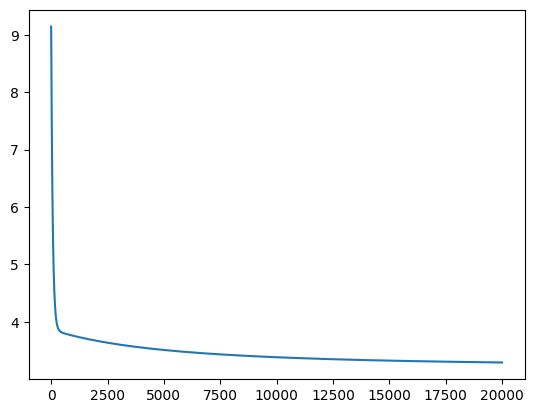

In [131]:
# Put your code here (1 line of code)
# Choose an initial value for model parameters, use Init_param function
w_init = Init_param(p)

# Put your code here (1 line of code)
# Choose the learning rate
alf = 0.005

# Put your code here (1 line of code)
# Choose the number of iterations
N = 20000

# Choose the regularization parameter
lam = 50

# Save the values for W and the COST values
W = np.zeros((p + 1, N+1))

COST = np.zeros(N + 1)

# Save initial values
W[:,0] = np.squeeze(w_init)
COST[0] = cost_fun_reg(X, Y, w_init, lam)

# This is a for loop to implement the Gradient Descent algorithm
for n in range(N):
    
    # Put your code here (1 line of code)
    # Use grad_descent_step to update the values for w
    w_new = grad_descent_step_reg(X, Y, W[:, n], alf, lam)
    
    # Save the new value for w
    W[:, n + 1] = w_new
    
    # Put your code here (1 line of code)
    # Save the cost value for newly obtained w using the cost_fun_reg
    COST[n+1] = cost_fun_reg(X, Y, W[:, n], lam)

# Plot the results
plt.plot(range(N+1),COST)
plt.show()

#### Plot the model coefficients versus iteration

Let's plot the model coefficients versus the iterations in the following cell.

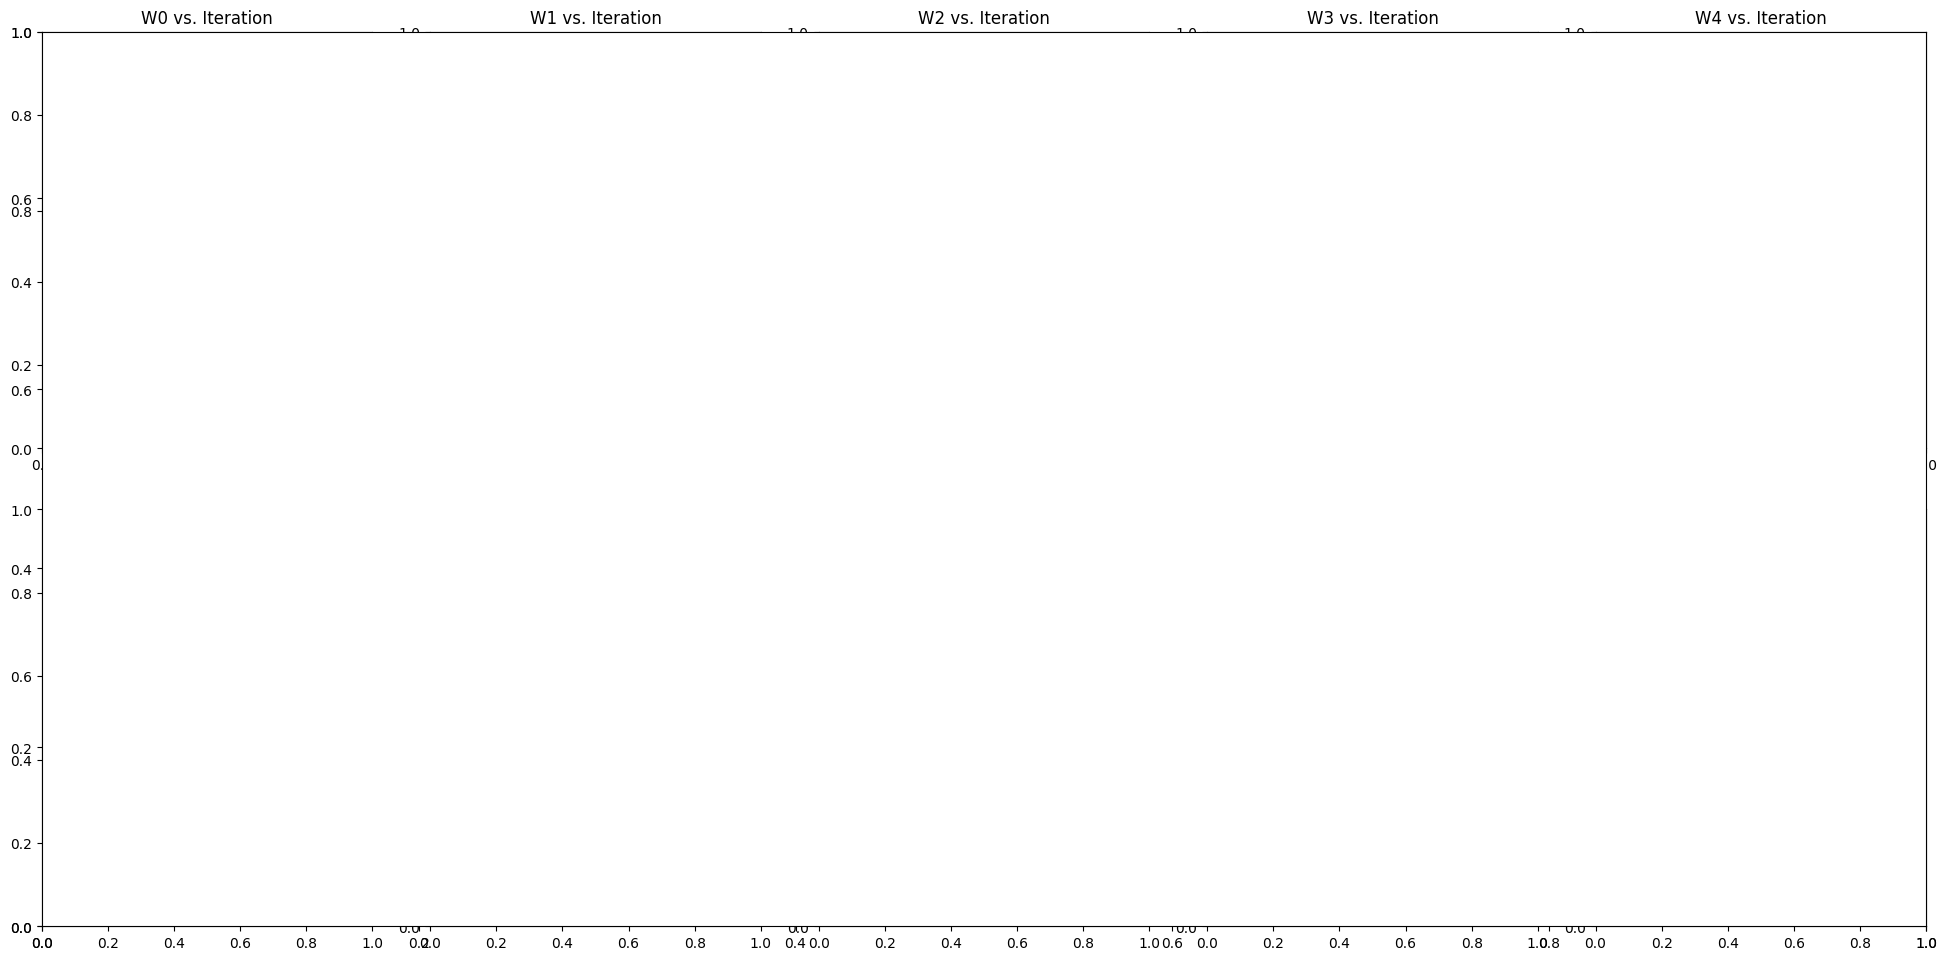

In [87]:
# Put your code here (1 lines of code)
# Choose number of rows and columns for illustrating W vs. Iteration
# Create a grid of subplots 
# You can change the number of rows and columns in the subplot
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

# Put your code here (2 lines of code)
# Plot on the first subplot W[0] vs. Iteration
plt.subplot(1,1,1)
axes[0,0].set_title(label="W0 vs. Iteration")

# Put your code here (2 line of code)
# Plot on the second subplot W[1] vs. Iteration
plt.subplot(1,1,1)
axes[0,1].set_title("W1 vs. Iteration")

# Put your code here (2 lines of code)
# Plot on the second subplot W[2] vs. Iteration
plt.subplot(1,1,1)
axes[0,2].set_title("W2 vs. Iteration")

# Put your code here (2 line of code) 
# Plot on the fourth subplot W[3] vs. Iteration
plt.subplot(1,1,1)
axes[0,3].set_title("W3 vs. Iteration")

# Put your code here (1 line of code) 
# You can remove it if you have just 3 features
# Plot on the fourth subplot W[4] vs. Iteration
plt.subplot(1,1,1)
axes[0,4].set_title("W4 vs. Iteration")


# Put your code here (2 lines of code)
# Plot on the first subplot W[0] vs. Iteration
plt.subplot(1,1,1)
axes[1,0].set_title(label="W0 vs. Iteration")

# Put your code here (2 line of code)
# Plot on the second subplot W[1] vs. Iteration
plt.subplot(1,1,1)
axes[1,1].set_title("W1 vs. Iteration")

# Put your code here (2 lines of code)
# Plot on the second subplot W[2] vs. Iteration
plt.subplot(1,1,1)
axes[1,2].set_title("W2 vs. Iteration")

# Put your code here (2 line of code) 
# Plot on the fourth subplot W[3] vs. Iteration
plt.subplot(1,1,1)
axes[1,3].set_title("W3 vs. Iteration")

# Put your code here (1 line of code) 
# You can remove it if you have just 3 features
# Plot on the fourth subplot W[4] vs. Iteration
plt.subplot(1,1,1)
axes[1,4].set_title("W4 vs. Iteration")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

#### Find the optimal coefficient values

The model has been trained, and you need to find the optimal coefficient values. In fact, the optimal coefficient values are the last saved values.

In [132]:
# Put your code here ( 1 line of code)
# Find the last obtained parameter values from the algorithm; 
# you have already save all the values in W
W_opt = W[:,-1]

print('The obtained coefficient values are:',W_opt)

The obtained coefficient values are: [ 0.43184838 -0.20959403  1.92506149 -0.07553485  4.27284079  0.94856395
  6.56386419  0.08628265  1.0542995   0.49825099  2.25657626]


#### Plot the cost function values versus iteration

Now, you can plot the cost function values versus iterations in the following cell.

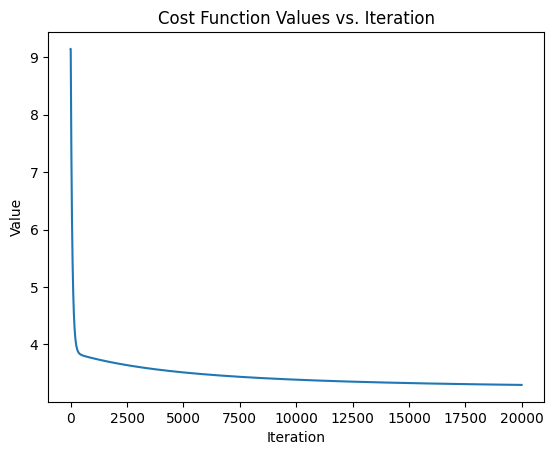

In [133]:
# Put your code here (1 line of code)
# Plot the cost function values per iteration; these values are already saved in COST.
plt.plot(COST)

plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Cost Function Values vs. Iteration')
plt.show()

### Evaluate your model using a test dataset

Note that for the final evaluation, even when you train the model with regularization, you should evaluate the model using `cost_fun`, not `cost_fun_reg`. The reason is that `cost_fun` computes the mean squared error between the predicted output and the true output, which is the relevant metric for the final model performance evaluation.

In [134]:
# Put your code here (1 line of code)
# Compute the mean square error using the cost_fun
# You have to use X_t and Y_t to evaluate your model
mse = cost_fun (X_t, Y_test, W[:, -1])

rmse = np.sqrt(mse)
print(rmse)

1.8216926830504676


## Hypreparameter Tuning

You managed to implement linear regression with regularization—__Congratulations__!

Now, it's time to find an appropriate set of hyperparameters. Please try at least three different sets of hyperparameters and fill in the table below. The table is pre-filled with some arbitrary values, but you should modify them based on your implementation.
We have considered both implementations—with and without regularization—where the $N$ and $\alpha$ values are the same for each set. Please follow this approach to enable a fair comparison of model performances. Replace the __None__ values in the table with your chosen hyperparameter sets.

__Note__: You may try more than three sets, but for the sake of documentation, please include three sets that you believe best demonstrate how hyperparameters affect the final model performance. 

| Set |  Method               | $N$    | $\alpha$ | $\lambda$ | RMSE | 
|-----|:----------------------|--------|----------|-----------|------|
|Set 1| Without Regularization|  10000 | 0.01     |  ---      | 1.82 |
|     | With Regularization   |  10000 | 0.01     |   10      | 1.81 |   
|Set 2| Without Regularization|  15000 | 0.001    |  ---      | 1.65 |
|     | With Regularization   |  15000 | 0.001    |   20      | 1.66 |
|Set 3| Without Regularization|  7000  | 0.005    |  ---      | 1.93 |
|     | With Regularization   |  7000  | 0.005    |   30      | 1.92 |

#### Best hyperparameters

Based on the hyperparameter tuning you have done, what are the best hyperparameters you found? (Fill in the 'None' values in the table below.)

__Best hyperparameters__:

|     Method            | $N$    | $\alpha$ | $\lambda$ | RMSE | 
|:----------------------|--------|----------|-----------|------|
| None                  |  None  | None     |  None     | None |    

In [135]:
best_hyperparameters = {
    "Set": ["Set 1", "", "Set 2", "", "Set 2", "",],
    "Method": ["Without Regularization", "With Regularization", "Without Regularization", "With Regularization", "Without Regularization", "With Regularization"],
    "N": ["1000", "1000", "10000", "10000", "20000", "20000"],
    "a": ["0.1", "0.1", "0.01", "0.01", "0.005", "0.005"],
    "lam": ["--", "5", "--", "20", "--", "50"],
    "RMSE": [1.8232903329504162, 1.8233785819972115, 1.8217426133294257, 1.8213605423968855, 1.8203341942499958, 1.8216926830504676],
}

best_hyperparameters_df = pd.DataFrame(best_hyperparameters)
print(best_hyperparameters_df)

     Set                  Method      N      a lam      RMSE
0  Set 1  Without Regularization   1000    0.1  --  1.823290
1            With Regularization   1000    0.1   5  1.823379
2  Set 2  Without Regularization  10000   0.01  --  1.821743
3            With Regularization  10000   0.01  20  1.821361
4  Set 2  Without Regularization  20000  0.005  --  1.820334
5            With Regularization  20000  0.005  50  1.821693
